In [13]:
import pandas as pd

# Leemos el archivo JSON que contiene mis partidas y lo convertimos en un DataFrame de pandas
df = pd.read_json("mis_partidas_rapid.json")

In [21]:
df.iloc[0, :]['white']

{'rating': 875,
 'result': 'win',
 '@id': 'https://api.chess.com/pub/player/pablo07as',
 'username': 'Pablo07as',
 'uuid': 'e34dc59a-6d19-11eb-8685-edbf2922a2c4'}

In [30]:
df['fecha_hora'] = pd.to_datetime(df['end_time'], unit='s')
 
df['fecha_hora'] = df['fecha_hora'].dt.tz_localize('UTC').dt.tz_convert('Europe/Madrid')

df['hora_del_dia'] = df['fecha_hora'].dt.hour  
df['dia_semana'] = df['fecha_hora'].dt.day_name()  

def etiqueta_rango_2h(hora):
    # Usamos división entera para agrupar. Ej: 15 // 2 = 7; 7 * 2 = 14.
    inicio = (hora // 2) * 2
    # Formateamos para que quede bonito: "14:00-15:59"
    return f"{inicio:02d}:00-{inicio+1:02d}:59"

# Creamos la nueva columna de franjas horarias
df['rango_2h'] = df['hora_del_dia'].apply(etiqueta_rango_2h)

# Comprobamos que ha salido bien
display(df[['end_time', 'fecha_hora', 'dia_semana', 'hora_del_dia', 'rango_2h']].head())

,end_time,fecha_hora,dia_semana,hora_del_dia,rango_2h
0,2021-02-12 10:29:43,2021-02-12 11:29:43+01:00,Friday,11,10:00-11:59
1,2021-02-12 21:47:55,2021-02-12 22:47:55+01:00,Friday,22,22:00-23:59
2,2021-02-15 10:52:06,2021-02-15 11:52:06+01:00,Monday,11,10:00-11:59
3,2021-02-15 11:15:31,2021-02-15 12:15:31+01:00,Monday,12,12:00-13:59
4,2021-02-15 17:12:03,2021-02-15 18:12:03+01:00,Monday,18,18:00-19:59


In [43]:
import pandas as pd
import numpy as np

usuario = "pablo07as"

def victoria(fila):
    # Comprobamos si jugabas con blancas y ganaste
    if fila['white']['username'].lower() == usuario and fila['white']['result'] == 'win':
        return 1
    # Comprobamos si jugabas con negras y ganaste
    elif fila['black']['username'].lower() == usuario and fila['black']['result'] == 'win':
        return 1
    # Si perdiste o fue empate
    return 0

# Aplicamos la función para crear la nueva columna
df['victoria'] = df.apply(victoria, axis=1)

# Le decimos a Pandas el orden lógico de los días, si no, los pondrá alfabéticamente
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=dias_orden, ordered=True)

agrupado = df.groupby(['dia_semana', 'rango_2h'], observed=False)['victoria'].agg(['mean', 'count']).reset_index()

# --- 3. FILTRAR POR VOLUMEN MÍNIMO ---
UMBRAL_PARTIDAS = 20

# np.where funciona como un "IF" de Excel: si hay 5 o más partidas, guardamos el porcentaje. Si no, ponemos "NaN" (nulo).
agrupado['win_rate_limpio'] = np.where(
    agrupado['count'] >= UMBRAL_PARTIDAS, 
    agrupado['mean'], 
    np.nan
)
# Creamos la tabla dinámica: cruza días (filas) con horas (columnas) y calcula la media de victorias
mapa_datos = agrupado.pivot(
    index='dia_semana', 
    columns='rango_2h', 
    values='win_rate_limpio'
) * 100 # Multiplicamos por 100 para que se lea como porcentaje (ej. 55%)

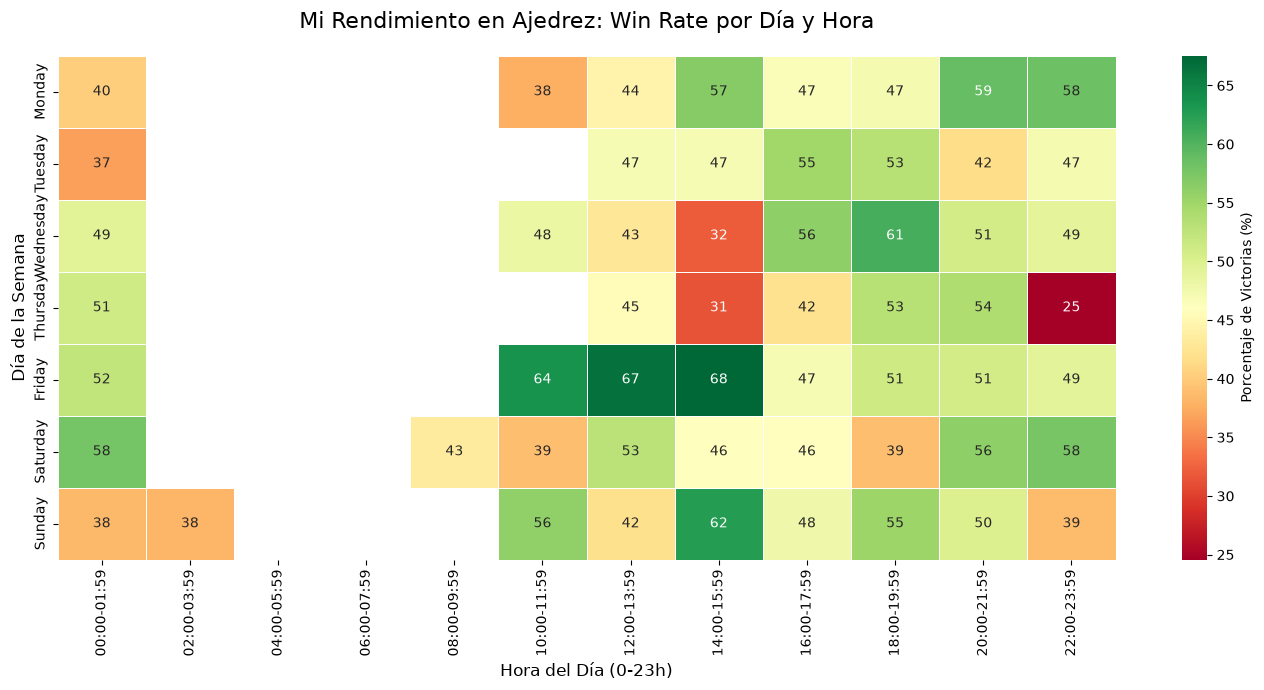

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño del lienzo (ancho, alto)
plt.figure(figsize=(14, 7))

# Pintamos el Heatmap. 
# cmap="RdYlGn" usa un gradiente de Rojo (Red) para malo a Verde (Green) para bueno.
# annot=True escribe el número dentro del cuadradito. fmt=".0f" le quita los decimales.
sns.heatmap(
    mapa_datos, 
    cmap="RdYlGn", 
    annot=True, 
    fmt=".0f", 
    linewidths=0.5, # Pone una pequeña línea de separación entre celdas
    cbar_kws={'label': 'Porcentaje de Victorias (%)'}
)

# Añadimos títulos y etiquetas para que quede como un informe profesional
plt.title('Mi Rendimiento en Ajedrez: Win Rate por Día y Hora', fontsize=16, pad=20)
plt.xlabel('Hora del Día (0-23h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)

# Muestra el gráfico
plt.tight_layout()
plt.show()